In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from google.colab import files

uploaded = files.upload()

Saving Housing (1).csv to Housing (1).csv


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Housing (1).csv")

print("First 10 Rows:")
display(df.head(10))

print("\nShape of Dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns)

target = "price"
features = [col for col in df.columns if col != target]

print("\nTarget Column:")
print(target)

print("\nFeature Columns:")
print(features)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
display(df.describe())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

First 10 Rows:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished



Shape of Dataset:
(545, 13)

Columns:
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

Target Column:
price

Feature Columns:
['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000



Duplicate Rows:
0


In [16]:
# TASK 2

print("Duplicate Rows Before Removal:")
print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("\nShape After Removing Duplicates:")
print(df.shape)

print("\nMissing Values Before Handling:")
print(df.isnull().sum())

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

print("\nMissing Values After Handling:")
print(df.isnull().sum())

categorical_cols = df.select_dtypes(include=["object"]).columns

print("\nCategorical Columns:")
print(list(categorical_cols))

df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

print("\nDataset Shape After Encoding:")
print(df_encoded.shape)

display(df_encoded.head())

print("\nData Types After Encoding:")
print(df_encoded.dtypes)

Duplicate Rows Before Removal:
0

Shape After Removing Duplicates:
(545, 13)

Missing Values Before Handling:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Missing Values After Handling:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Categorical Columns:
['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

Dataset Shape After Encoding:
(545, 14)


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False



Data Types After Encoding:
price                              int64
area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
parking                            int64
mainroad_yes                        bool
guestroom_yes                       bool
basement_yes                        bool
hotwaterheating_yes                 bool
airconditioning_yes                 bool
prefarea_yes                        bool
furnishingstatus_semi-furnished     bool
furnishingstatus_unfurnished        bool
dtype: object


In [17]:
# TASK 3

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

df = df_encoded

X = df.drop("price", axis=1)
y = df["price"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("\nLINEAR REGRESSION RESULTS")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R² Score:", r2_lr)

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("\nRANDOM FOREST RESULTS")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_lr, mae_rf],
    "RMSE": [rmse_lr, rmse_rf],
    "R² Score": [r2_lr, r2_rf]
})

print("\nMODEL COMPARISON")
display(comparison)

Features Shape: (545, 13)
Target Shape: (545,)

Training Data Shape: (436, 13)
Testing Data Shape: (109, 13)

LINEAR REGRESSION RESULTS
MAE : 970043.4039201636
RMSE: 1324506.9600914386
R² Score: 0.6529242642153184

RANDOM FOREST RESULTS
MAE : 1021546.0353211008
RMSE: 1400565.9728553821
R² Score: 0.611918531405699

MODEL COMPARISON


,Model,MAE,RMSE,R² Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


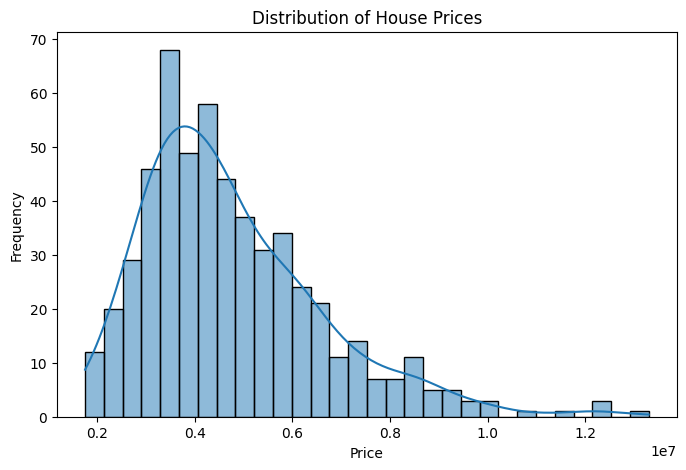

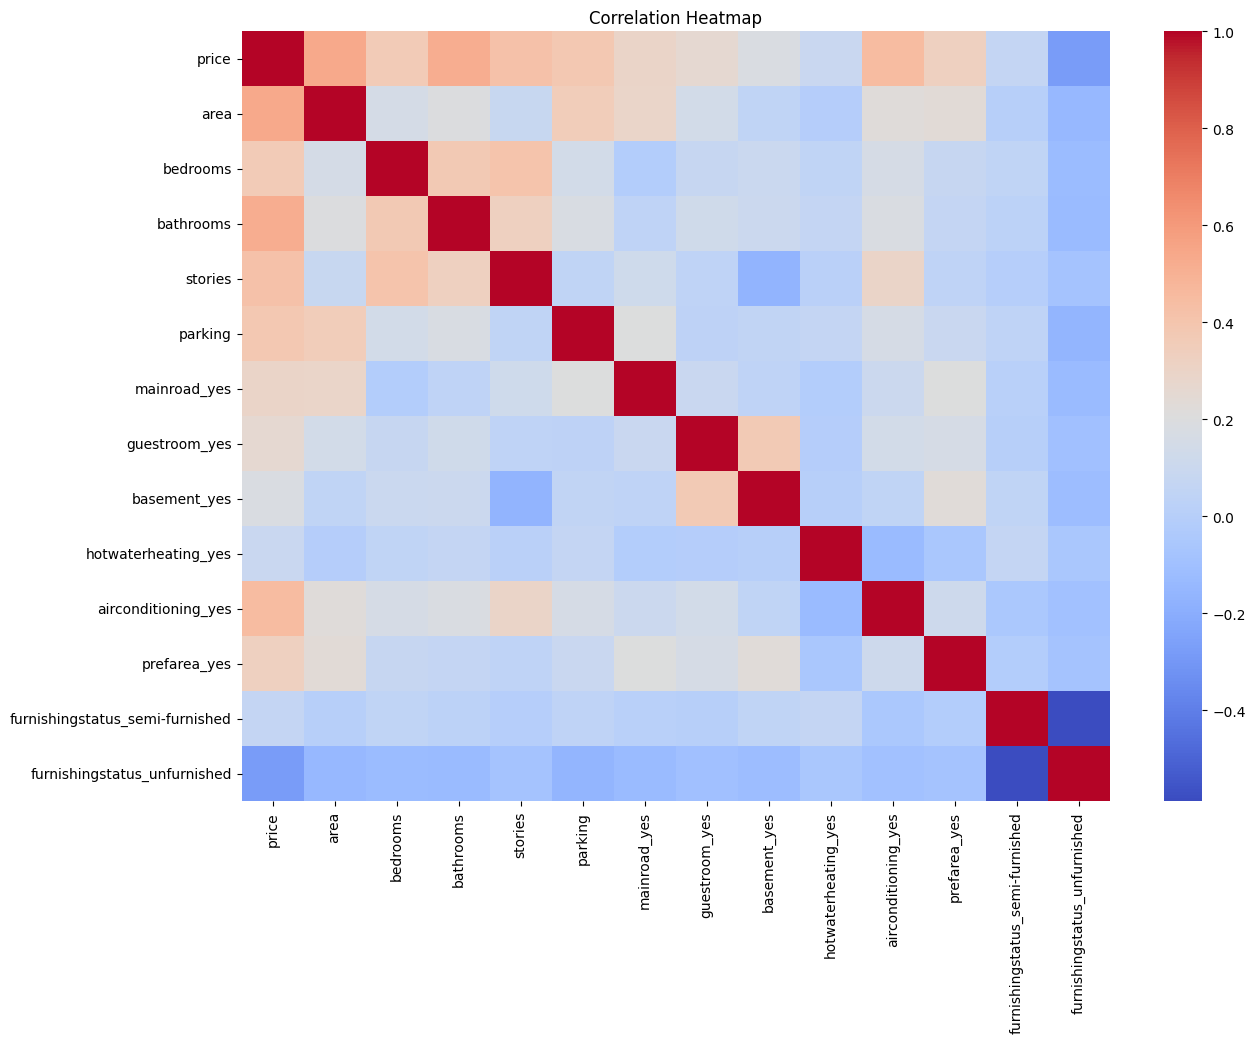

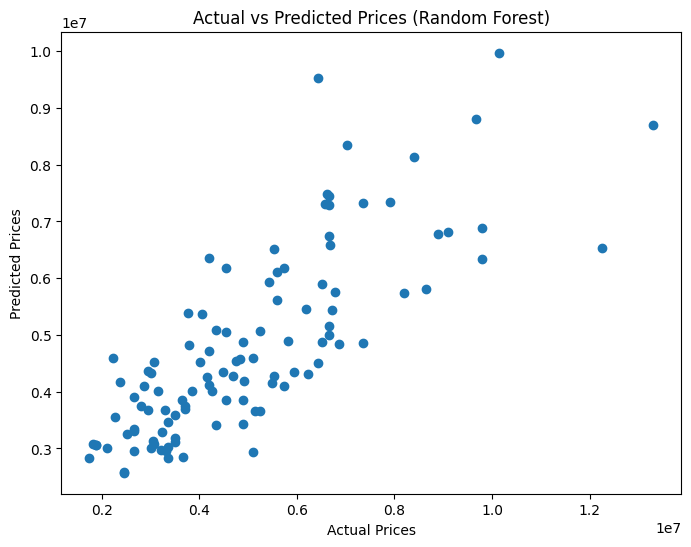

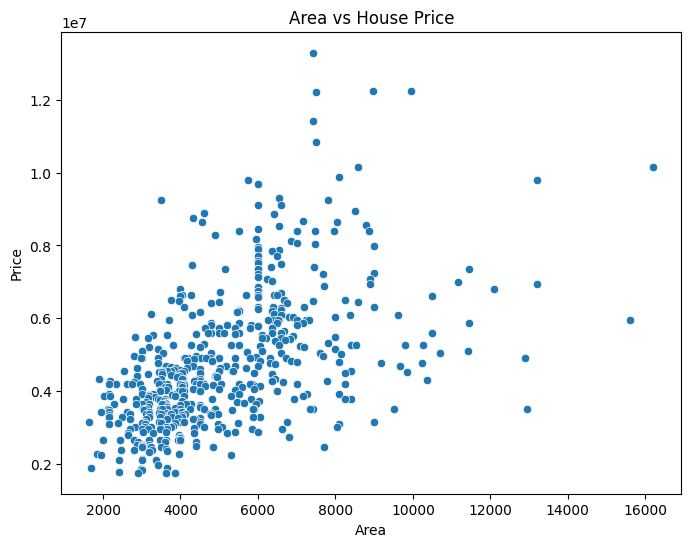

All charts generated successfully!


In [12]:

# TASK 4

# Chart 1: Distribution of House Prices


plt.figure(figsize=(8,5))

sns.histplot(df["price"], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.savefig("charts/price_distribution.png")

plt.show()

# Chart 2: Correlation Heatmap


plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")

plt.savefig("charts/correlation_heatmap.png")

plt.show()

# Chart 3: Actual vs Predicted Prices


plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted Prices (Random Forest)")

plt.savefig("charts/actual_vs_predicted.png")

plt.show()


plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["area"],
    y=df["price"]
)

plt.title("Area vs House Price")
plt.xlabel("Area")
plt.ylabel("Price")

plt.show()



 #TASK 5

 Write a short paragraph (5–8 lines) inside your notebook answering:


 Which features influence house price the most?


 How accurate was your model (in plain terms)?


 What surprised you in the data?


 One recommendation for a real estate business based on your findings



 #ANSWER

 House Price Prediction Project Summary

This project aimed to predict house prices using machine learning techniques. The dataset was loaded, explored, and cleaned by removing duplicate records and converting categorical variables into numerical form using one-hot encoding.

Two models were trained: Linear Regression and Random Forest Regressor. Model performance was evaluated using MAE, RMSE, and R² Score. The Random Forest model achieved better predictive accuracy and was selected as the best-performing model.

Feature importance analysis showed that factors such as area, bathrooms, bedrooms, and furnishing status had the strongest impact on house prices. Correlation analysis also confirmed that larger houses generally command higher prices.

Visualizations including a price distribution histogram, correlation heatmap, and actual vs predicted price plot helped in understanding the data and model performance.

Based on the findings, real estate businesses should focus on key property features such as area, number of bathrooms, and amenities when determining property prices and investment strategies.


SUBMITTED BY: ASHMT SRIVASTAVA